In [1093]:
import numpy as np
import pandas as pd
import random
import json
from datasets import load_dataset, concatenate_datasets

random.seed(42)

In [1094]:
combined_cs_df = pd.DataFrame(columns=["codeswitch_sentence", "languages"])

In [1095]:
combined_cs_df.head()

,codeswitch_sentence,languages


CSPref [English-Malayalam, Eng-Hindi, English-Tamil]

CSPref is a curated human preference dataset for evaluating the fluency and accuracy of code-switched text generation. Built specifically for multilingual NLP research, CSPREF is designed to help researchers and developers tune and evaluate models for code-switching tasks across diverse language pairs. The dataset provides valuable insights into human preferences, allowing for better alignment of language models with natural code-switching patterns and improving the quality of generated multilingual content.

https://huggingface.co/datasets/garrykuwanto/cspref

In [1096]:
# REMOVING FOR NOW BECAUSE IT IS NOT CLEAN

# splits = {'train': 'data/train-00000-of-00001.parquet', 'test': 'data/test-00000-of-00001.parquet'}
# cspref_df = pd.read_parquet("hf://datasets/garrykuwanto/cspref/" + splits["train"])
# cspref_df.head()
# def resolve_choice(row):
#     if row['chosen'] == 'sent_1':
#         return row['sent_1']
#     elif row['chosen'] == 'sent_2':
#         return row['sent_2']

# cspref_df['codeswitch_sentence'] = cspref_df.apply(resolve_choice, axis=1)
# cspref_df['languages'] = cspref_df['lang']

# combined_cs_df['codeswitch_sentence'] = cspref_df['codeswitch_sentence']
# combined_cs_df['languages'] = cspref_df['languages']

# combined_cs_df.head()
# unique_sentences = combined_cs_df['codeswitch_sentence'].unique()
# unique_sentences
# combined_cs_df
# combined_cs_df = combined_cs_df.drop_duplicates(subset='codeswitch_sentence', keep='first')

# combined_cs_df
# cspref_subset = combined_cs_df

BaSCo Basque–Spanish dataset
https://github.com/Vicomtech/BaSCo-Corpus


In [1097]:
with open('subdatasets/BaSCo/valid_utterances.json', 'r', encoding='utf-8') as f:
    basco_data = json.load(f)

In [1098]:
basco_data

[{'domain': 'fiscal',
  'intents': ['informar_canal', 'informar_documento', 'preguntar_tramite'],
  'source_lang': 'es',
  'referent': 'es la web una de las formas para pedir las claves de renta?',
  'entities': [{'entity': 'canal',
    'value': 'web',
    'normative_value': 'web',
    'start': 6,
    'end': 8,
    'type': 'bounded'},
   {'entity': 'tramite',
    'value': 'pedir',
    'normative_value': 'solicitar',
    'start': 33,
    'end': 37,
    'type': 'bounded'},
   {'entity': 'documento',
    'value': 'claves de renta',
    'normative_value': 'claves-renta',
    'start': 43,
    'end': 57,
    'type': 'bounded'}],
  'code-switching': [{'text': 'web-a kanal on bat da para pedir las claves de la renta?',
    'entities': [{'entity': 'canal',
      'value': 'web-a',
      'normative_value': 'web',
      'start': 0,
      'end': 4,
      'type': 'bounded'},
     {'entity': 'tramite',
      'value': 'pedir',
      'normative_value': 'solicitar',
      'start': 27,
      'end': 31,
 

In [1099]:
cs_entries = []
for item in basco_data:
    for cs in item.get('code-switching', []):
        cs_entries.append({
            'codeswitch_sentence': cs['text'].strip(),
            'languages': 'Basque–Spanish'
        })

In [1100]:
cs_basco_df = pd.DataFrame(cs_entries)

In [1101]:
cs_basco_df = cs_basco_df.drop_duplicates(subset='codeswitch_sentence').reset_index(drop=True)

In [1102]:
cs_basco_df

,codeswitch_sentence,languages
0,web-a kanal on bat da para pedir las claves de...,Basque–Spanish
1,eska daitezke via web las claves de la renta?,Basque–Spanish
2,donostiako hacienda edifizioa,Basque–Spanish
3,donostiako haziendako edifizioa,Basque–Spanish
4,edificio de ogasuna donostian,Basque–Spanish
...,...,...
1367,zelan doa la zonificacion,Basque–Spanish
1368,rektifikazioen plazoak esango dizkidazu?,Basque–Spanish
1369,cuál es tu adina?,Basque–Spanish
1370,viejoa zara?,Basque–Spanish


In [1103]:
combined_cs_df = pd.concat([combined_cs_df, cs_basco_df], ignore_index=True)

In [1104]:
combined_cs_df

,codeswitch_sentence,languages
0,web-a kanal on bat da para pedir las claves de...,Basque–Spanish
1,eska daitezke via web las claves de la renta?,Basque–Spanish
2,donostiako hacienda edifizioa,Basque–Spanish
3,donostiako haziendako edifizioa,Basque–Spanish
4,edificio de ogasuna donostian,Basque–Spanish
...,...,...
1367,zelan doa la zonificacion,Basque–Spanish
1368,rektifikazioen plazoak esango dizkidazu?,Basque–Spanish
1369,cuál es tu adina?,Basque–Spanish
1370,viejoa zara?,Basque–Spanish


Dravidian-CodeMix

Tamil-English: 15744 comments, Train: 11,335 Validation: 1,260 and Test: 3,149

Malayalam-English: 6,739 comments, Train: 4,851 Validation: 541 and Test: 1,348

We present Tamil-English and Malayalam-English, a dataset of YouTube video comments. The dataset contains all the three types of code-mixed sentences -- Inter-Sentential switch, Intra-Sentential switch and Tag switching. Most comments were written in Roman script with either Tamil / Malayalam grammar with English lexicon or English grammar with Tamil / Malayalam lexicon. Some comments were written in Tamil / Malayalam script with English expressions in between.

https://dravidian-codemix.github.io/2020/datasets.html

In [1105]:
malayalam_dev_df = pd.read_csv("subdatasets/Dravidian-CodeMix/Malayalam-English/train/malayalam_dev.tsv", sep='\t')
malayalam_train_df = pd.read_csv("subdatasets/Dravidian-CodeMix/Malayalam-English/train/malayalam_train.tsv", sep='\t')

In [1106]:
malayalam_dev_df = malayalam_dev_df[malayalam_dev_df['category'] != 'not-malayalam']
malayalam_train_df = malayalam_train_df[malayalam_train_df['category'] != 'not-malayalam']

In [1107]:
malayalam_df = pd.concat([malayalam_dev_df, malayalam_train_df], ignore_index=True)

In [1108]:
malayalam_subset = malayalam_df[['text']].copy()
malayalam_subset = malayalam_subset.rename(columns={'text': 'codeswitch_sentence'})
malayalam_subset['languages'] = 'Malayalam–English'

In [1109]:
malayalam_subset = malayalam_subset.drop_duplicates(subset='codeswitch_sentence').reset_index(drop=True)

In [1110]:
malayalam_subset

,codeswitch_sentence,languages
0,speechless 🤐. ikkaaa,Malayalam–English
1,Raja sollunathu mattuthaam seyyvaa seyyunnath...,Malayalam–English
2,Im Prithiviraj fan from tamilnadu... Love it,Malayalam–English
3,mohanlal sir - look ..... kiddo...,Malayalam–English
4,Kandathil vech mungiya pdam Rating 1.1/5,Malayalam–English
...,...,...
5372,Madhuraraja trailer Kand ivide vannanvar likkeee,Malayalam–English
5373,Njn pru lalettan fan ahn.. eee trailer mass ...,Malayalam–English
5374,Valiya pratheesha illa nalla entertainment a...,Malayalam–English
5375,Dislike adikkunna kazhuthakalude mukhath adik...,Malayalam–English


In [1111]:
malayalam_test_df = pd.read_csv("subdatasets/Dravidian-CodeMix/Malayalam-English/test/malayalam_test_results - malayalam_test_results.csv")

In [1112]:
malayalam_test_df = malayalam_test_df[malayalam_test_df['category'] != 'not-malayalam']

In [1113]:
malayalam_test_subset = malayalam_test_df[['text']].copy()
malayalam_test_subset = malayalam_test_subset.rename(columns={'text': 'codeswitch_sentence'})
malayalam_test_subset['languages'] = 'Malayalam–English'

In [1114]:
full_malayalam_subset = pd.concat([malayalam_subset, malayalam_test_subset], ignore_index=True)

In [1115]:
full_malayalam_subset = full_malayalam_subset.drop_duplicates(subset='codeswitch_sentence').reset_index(drop=True)

In [1116]:
combined_cs_df = pd.concat([combined_cs_df, full_malayalam_subset], ignore_index=True)

In [1117]:
combined_cs_df

,codeswitch_sentence,languages
0,web-a kanal on bat da para pedir las claves de...,Basque–Spanish
1,eska daitezke via web las claves de la renta?,Basque–Spanish
2,donostiako hacienda edifizioa,Basque–Spanish
3,donostiako haziendako edifizioa,Basque–Spanish
4,edificio de ogasuna donostian,Basque–Spanish
...,...,...
7914,Enta ponno eppolu ntha oru ethu,Malayalam–English
7915,143k views and 145k likes,Malayalam–English
7916,Nasik doll tiltle bgm aane highlight,Malayalam–English
7917,Mohanlalile ishtapetta vekthiyayirunnu njan pa...,Malayalam–English


In [1118]:
tamil_dev_df = pd.read_csv("subdatasets/Dravidian-CodeMix/Tamil-English/train/tamil_dev.tsv", sep='\t')
tamil_train_df = pd.read_csv("subdatasets/Dravidian-CodeMix/Tamil-English/train/tamil_train.tsv", sep='\t')

In [1119]:
tamil_dev_df = tamil_dev_df[tamil_dev_df['category'] != 'not-Tamil ']
tamil_train_df = tamil_train_df[tamil_train_df['category'] != 'not-Tamil']

In [1120]:
tamil_df = pd.concat([tamil_dev_df, tamil_train_df], ignore_index=True)

In [1121]:
tamil_subset = tamil_df[['text']].copy()
tamil_subset = tamil_subset.rename(columns={'text': 'codeswitch_sentence'})
tamil_subset['languages'] = 'Tamil–English'

In [1122]:
tamil_subset = tamil_subset.drop_duplicates(subset='codeswitch_sentence').reset_index(drop=True)

In [1123]:
tamil_subset

,codeswitch_sentence,languages
0,Daily likes & views pakka vanthavaga ellaruku...,Tamil–English
1,25 k dislikes ethuku da intha trailerku poi a...,Tamil–English
2,#Lyca unna nenacha pavama iruku ya,Tamil–English
3,It looks like Hindi movie amitab bachan,Tamil–English
4,Thalaivarukku nejamavey vayasaagiduchu... siv...,Tamil–English
...,...,...
12443,Yuvan shankar Raja anna fan's like here...,Tamil–English
12444,A masterpiece best revenge film I’ve ever scene,Tamil–English
12445,Enna pa thala ya kamiya than katringa,Tamil–English
12446,R A A S H I K H A N N A,Tamil–English


In [1124]:
tamil_test_df = pd.read_csv("subdatasets/Dravidian-CodeMix/Tamil-English/test/tamil_test_answer - tamil_test_answer.csv")

In [1125]:
tamil_test_df = tamil_test_df[tamil_test_df['category'] != 'not-Tamil']

In [1126]:
tamil_test_subset = tamil_test_df[['text']].copy()
tamil_test_subset = tamil_test_subset.rename(columns={'text': 'codeswitch_sentence'})
tamil_test_subset['languages'] = 'Tamil–English'

In [1127]:
full_tamil_subset = pd.concat([tamil_subset, tamil_test_subset], ignore_index=True)

In [1128]:
full_tamil_subset = full_tamil_subset.drop_duplicates(subset='codeswitch_sentence').reset_index(drop=True)

In [1129]:
combined_cs_df = pd.concat([combined_cs_df, full_tamil_subset], ignore_index=True)

In [1130]:
combined_cs_df

,codeswitch_sentence,languages
0,web-a kanal on bat da para pedir las claves de...,Basque–Spanish
1,eska daitezke via web las claves de la renta?,Basque–Spanish
2,donostiako hacienda edifizioa,Basque–Spanish
3,donostiako haziendako edifizioa,Basque–Spanish
4,edificio de ogasuna donostian,Basque–Spanish
...,...,...
23404,Tamil krish ah irukum oh...,Tamil–English
23405,Thalaivaaaaaa... trailer ye pattaiya kelapudhe...,Tamil–English
23406,Innum neraya neraya neraya neraya neraya,Tamil–English
23407,1:05 to 1:30 Vere level masss,Tamil–English


English-Chinese


CroCoSum, a dataset of cross-lingual code-switched summarization sourced from a technology-oriented news forum.
https://huggingface.co/datasets/ruochenz/CroCoSum


ASCEND Chinese–English dataset:
https://huggingface.co/datasets/CAiRE/ASCEND

In [1131]:
def load_jsonl(file_path):
    data = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line))
    return data

In [1132]:
def create_subset(data):
    return pd.DataFrame([{
        'codeswitch_sentence': item['post_text'],
        'languages': 'Chinese–English'
    } for item in data])

In [1133]:
train_data = load_jsonl("subdatasets/CroCoSum/train.jsonl")
test_data = load_jsonl("subdatasets/CroCoSum/test.jsonl")
val_data = load_jsonl("subdatasets/CroCoSum/val.jsonl")

In [1134]:
train_subset = create_subset(train_data)
test_subset = create_subset(test_data)
val_subset = create_subset(val_data)

In [1135]:
full_chinese_subset = pd.concat([train_subset, test_subset, val_subset], ignore_index=True)

In [1136]:
full_chinese_subset = full_chinese_subset.drop_duplicates(subset='codeswitch_sentence').reset_index(drop=True)

In [1137]:
combined_cs_df = pd.concat([combined_cs_df, full_chinese_subset], ignore_index=True)

In [1138]:
combined_cs_df

,codeswitch_sentence,languages
0,web-a kanal on bat da para pedir las claves de...,Basque–Spanish
1,eska daitezke via web las claves de la renta?,Basque–Spanish
2,donostiako hacienda edifizioa,Basque–Spanish
3,donostiako haziendako edifizioa,Basque–Spanish
4,edificio de ogasuna donostian,Basque–Spanish
...,...,...
41957,投资人和电视明星 Kevin O'Leary 称他永远也不会花 2.5 美元买一杯咖啡。他解...,Chinese–English
41958,特斯拉开始向其电动汽车推送新的更新，将的系统具有部分自主驾驶功能，但并没有Google汽车的...,Chinese–English
41959,上个月发布的文件系统 ZFS on Linux 0.7.7 发现了数据损失 bug。当用户尝...,Chinese–English
41960,自《侏罗纪公园》上映以来，古生物学家就一直开有关琥珀内恐龙的玩笑。现在这个玩笑变成真的了。中...,Chinese–English


ASCEND

In [1139]:
ascend_ds = load_dataset("CAiRE/ASCEND")

In [1140]:
all_splits = concatenate_datasets([ascend_ds['train'], ascend_ds['test'], ascend_ds['validation']])

In [1141]:
mixed_data = all_splits.filter(lambda x: x['language'] == 'mixed', num_proc=4)

In [1142]:
ascend_subset = pd.DataFrame({
    'codeswitch_sentence': mixed_data['transcription'],
    'languages': 'English-Chinese'
})

In [1143]:
ascend_subset = ascend_subset.drop_duplicates(subset='codeswitch_sentence').reset_index(drop=True)

In [1144]:
combined_cs_df = pd.concat([combined_cs_df, ascend_subset], ignore_index=True)

Hindi-English
https://drive.google.com/drive/folders/1sxU4PpFZs86ncad_iak4U6AY_2wOsayj


https://zenodo.org/records/3974927#.XyxAZCgzZPZ

HinGE

In [1145]:
filename = 'subdatasets/HinGE/HinGE.pkl'
hinge_df = pd.read_pickle(filename)
hinge_df.head()

,English,Hindi,Human-generated Hinglish,WAC,WAC rating1,WAC rating2,PAC,PAC rating1,PAC rating2
0,It was presented to the Legislative Council in...,इसे 1856 में विधायी परिषद के समक्ष प्रस्तुत कि...,[Ise 1856 mein legislative council ke samaksh ...,ise 1856 men legislative council ke samaksh pr...,9,6,ise 1856 men legislative council ke samaksh pr...,9,8
1,"In the year 1985-86, the erstwhile Ministry of...",वर्ष 1985-86 में पूर्ववर्ती कल्याण मंत्रालय को...,"[In the year 1985-86, purvarti kalyan mantrala...",year 1985-86 men poorvavarti welfare ministry ...,10,4,year 1985-86 men poorvavarti kalyan mntralay k...,10,10
2,"Connecting to the server, please wait...","सर्वर से कनेक्ट कर रहा है, कृपया इंतजार करें...","[Connecting to the server, kripya intezaar kar...","server se kanekt kar raha hai , wait intjar karen",5,5,"server se connecting kar raha hai, kripya wait...",9,9
3,He propagated the principles of Hinduism.,उसने हिन्दुत्व के नियमों का प्रचार किया।,[Usne principles of hinduism ka prachaar kiya....,usne hinduism ke principles ka prchar kiya.,10,8,usne principles of hinduism ka propagated kiya.,8,4
4,The game has no solution. Undo or start again.,खेल के पास कोई हल नहीं है. वापस ले या फिर शुरू...,[Khel ka koi solution nhi hai. Undo karein ya ...,game ke pas koee solution nahin hai vapas le ...,9,7,game ke pas koee hal nahin hai vapas le ya phi...,9,7


In [1146]:
hinge_df['Human-generated Hinglish'][0]

['Ise 1856 mein legislative council ke samaksh prastut kiya gya and 1860 mein paarit kiya gya.',
 'Ise 1856 mein vidhai parishad ko present kiya and 1860 mein pass kiya.',
 'It was presented to vidhayi parishad in 1856 aur 1860 me parit kiya gaya.',
 'Ise 1856 me legislative council ke samaksh present kiya gaya aur 1860  me pass kiya.',
 '1856 me it was presented to the legislative council aur 1860 me it was passed.',
 '1856 me ise legislative council ke samaksh prensent kiya gaya aur 1860 me parit kiya gaya.']

In [1147]:
hinge_df.shape

(1976, 9)

In [1148]:
new_rows = []
for idx, row in hinge_df.iterrows():
    for sentence in row['Human-generated Hinglish']:
        new_rows.append({'codeswitch_sentence': sentence, 'languages': 'Hindi-English'})

In [1149]:
hinglish_subset_df = pd.DataFrame(new_rows)

In [1150]:
hinglish_subset_df

,codeswitch_sentence,languages
0,Ise 1856 mein legislative council ke samaksh p...,Hindi-English
1,Ise 1856 mein vidhai parishad ko present kiya ...,Hindi-English
2,It was presented to vidhayi parishad in 1856 a...,Hindi-English
3,Ise 1856 me legislative council ke samaksh pre...,Hindi-English
4,1856 me it was presented to the legislative co...,Hindi-English
...,...,...
4794,Kagaj banate samay Recycled paper uses less na...,Hindi-English
4795,and seek forgiveness from Allah. Surely Allah ...,Hindi-English
4796,Allah se kshama ki prarthana karo. Nissandeh A...,Hindi-English
4797,This will be our tribute to Mahatma Gandhi 150...,Hindi-English


In [1151]:
combined_cs_df = pd.concat([combined_cs_df, hinglish_subset_df], ignore_index=True)

In [1152]:
combined_cs_df

,codeswitch_sentence,languages
0,web-a kanal on bat da para pedir las claves de...,Basque–Spanish
1,eska daitezke via web las claves de la renta?,Basque–Spanish
2,donostiako hacienda edifizioa,Basque–Spanish
3,donostiako haziendako edifizioa,Basque–Spanish
4,edificio de ogasuna donostian,Basque–Spanish
...,...,...
50076,Kagaj banate samay Recycled paper uses less na...,Hindi-English
50077,and seek forgiveness from Allah. Surely Allah ...,Hindi-English
50078,Allah se kshama ki prarthana karo. Nissandeh A...,Hindi-English
50079,This will be our tribute to Mahatma Gandhi 150...,Hindi-English


SemEval-2020 Task 9: Overview of Sentiment Analysis of Code-Mixed Tweets (Hindi-English and Spanish-English)

In [1153]:
import zipfile

zip_file = "subdatasets/SemEval/Semeval_2020_task9_data.zip"
extract_to = "subdatasets/SemEval"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

In [1154]:
hinglish_train_file = 'subdatasets/SemEval/Semeval_2020_task9_data/Hinglish/Hinglish_train_14k_split_conll.txt'

In [1155]:
def read_txt_sample(file_path, sample_size=5):
    sentences = []
    current_sentence = []

    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            if line.strip() == "":  
                if current_sentence:
                    sentences.append(current_sentence)
                    current_sentence = []
            else:
                current_sentence.append(line.strip())

    return sentences[:sample_size]

In [1156]:
sample_sentences = read_txt_sample(hinglish_train_file, sample_size=5)

In [1157]:
for idx, sentence in enumerate(sample_sentences, 1):
    print(f"Sentence {idx}:")
    for token in sentence:
        print(token)
    print("\n" + "="*40 + "\n")

Sentence 1:
meta	4330	neutral
nen	Eng
á	O
vist	Eng
bolest	Eng
vztek	Eng
smutek	Eng
zmatek	Hin
osam	Hin
ě	O
lost	Eng
beznad	Eng
ě	O
j	Hin
a	Eng
nakonec	Eng
jen	Hin
klid	Hin
Asi	Hin
takhle	Hin
vypad	Hin
á	O
m	Hin
ů	O
j	Eng
life	Eng
...	O


Sentence 2:
meta	41616	neutral
@	O
nehantics	Hin
Haan	Hin
yaar	Hin
neha	Hin
😔😔	O
kab	Hin
karega	Hin
woh	Hin
post	Hin
😭	EMT
Usne	Hin
na	Hin
sach	Hin
mein	Hin
photoshoot	Eng
karna	Hin
chahiye	Hin
phir	Hin
woh	Hin
post	Hin
karega	Hin
…	O
https	Eng
//	O
tco	Eng
/	O
5RSlSbZNtt	Eng


Sentence 3:
meta	6648	negative
@	O
RahulGandhi	Eng
television	Eng
media	Eng
congress	Eng
ke	Hin
liye	Hin
nhi	Hin
h	Hin
.	O
Ye	Hin
toh	Hin
aapko	Hin
pata	Hin
chal	Hin
hi	Hin
gya	Hin
hoga	Hin
.	O
Achha	Hin
hoga	Hin
ki	Hin
Congress	Hin
ke	Eng
…	O
https	Eng
//	O
t	Eng
.	O
co	Hin
/	O
HmH8M7PTaK	Hin


Sentence 4:
meta	2512	positive
@	O
AmitShah	Hin
@	O
narendramodi	Hin
All	Hin
India	Hin
me	Eng
nrc	Hin
lagu	Hin
kare	Hin
w	Eng
Kashmir	Hin
se	Hin
dhara	Eng
370ko	Eng
khatam	Hin
kare	Hin
h

In [1158]:
hinglish_train_file = "subdatasets/SemEval/Semeval_2020_task9_data/Hinglish/Hinglish_train_14k_split_conll.txt"
hinglish_dev_file = "subdatasets/SemEval/Semeval_2020_task9_data/Hinglish/Hinglish_dev_3k_split_conll.txt"
hinglish_test_file = "subdatasets/SemEval/Semeval_2020_task9_data/Hinglish/Hinglish_test_unalbelled_conll_updated.txt"

In [1159]:
def load_data(file_path, languages):
    sentences = []
    tokens = []

    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            line = line.strip()

            if line.startswith("meta"):
                if tokens:
                    sentence = " ".join(tokens)
                    sentences.append([sentence, languages])
                tokens = []

            else:
                parts = line.split("\t")
                token = parts[0]
                tokens.append(token)

        if tokens:
            sentence = " ".join(tokens)
            sentences.append([sentence, languages])

    df = pd.DataFrame(sentences, columns=['codeswitch_sentence', 'languages'])
    return df

In [1160]:
train_df = load_data(hinglish_train_file, 'Hindi-English')
dev_df = load_data(hinglish_dev_file, 'Hindi-English')
test_df = load_data(hinglish_test_file, 'Hindi-English')

In [1161]:
train_df

,codeswitch_sentence,languages
0,nen á vist bolest vztek smutek zmatek osam ě l...,Hindi-English
1,@ nehantics Haan yaar neha 😔😔 kab karega woh p...,Hindi-English
2,@ RahulGandhi television media congress ke liy...,Hindi-English
3,@ AmitShah @ narendramodi All India me nrc lag...,Hindi-English
4,@ Nehr _ who @ TypoMantri @ anjanaomkashyap Pa...,Hindi-English
...,...,...
13997,@ anandk2012 @ RailMinIndia @ IRCTCofficial @ ...,Hindi-English
13998,so i couldn't get no one to cover me for my bi...,Hindi-English
13999,RT @ theskindoctor13 @ NajimKhan07 Aap logo ki...,Hindi-English
14000,@ PriyaVerma __ @ ashutosh83B Jay Jay Shree Ra...,Hindi-English


In [1162]:
semeval_hinglish = pd.concat([train_df, dev_df, test_df], ignore_index=True)

In [1163]:
combined_cs_df = pd.concat([combined_cs_df, semeval_hinglish], ignore_index=True)

In [1164]:
combined_cs_df

,codeswitch_sentence,languages
0,web-a kanal on bat da para pedir las claves de...,Basque–Spanish
1,eska daitezke via web las claves de la renta?,Basque–Spanish
2,donostiako hacienda edifizioa,Basque–Spanish
3,donostiako haziendako edifizioa,Basque–Spanish
4,edificio de ogasuna donostian,Basque–Spanish
...,...,...
70079,@ i _ yogesh22 @ atulreellife Haha @ atulreell...,Hindi-English
70080,ðŸ™ðŸ™ðŸ™ you da realest . Thank you for pu...,Hindi-English
70081,RT @ Nimra _ Khan241 Fahad Bhaiiiii give us Bi...,Hindi-English
70082,RT @ fralaliciouxxe tbh i have bad sides too ....,Hindi-English


In [1165]:
spanglish_train_file = "subdatasets/SemEval/Semeval_2020_task9_data/Spanglish/Spanglish_train.conll"
spanglish_dev_file = "subdatasets/SemEval/Semeval_2020_task9_data/Spanglish/Spanglish_dev.conll"
spanglish_test_file = "subdatasets/SemEval/Semeval_2020_task9_data/Spanglish/spanglish_test_conll_unlabeled.txt"

In [1166]:
train_df = load_data(spanglish_train_file, 'Spanish-English')
dev_df = load_data(spanglish_dev_file, 'Spanish-English')
test_df = load_data(spanglish_test_file, 'Spanish-English')

In [1167]:
train_df

,codeswitch_sentence,languages
0,So that means tomorrow cruda segura lol,Spanish-English
1,Tonight peda segura,Spanish-English
2,Eres tan mala vieja bruja interesada #jamming,Spanish-English
3,Yo kiero Pretzels lol,Spanish-English
4,Fuck that ni ke el me vaya a mantener toda la ...,Spanish-English
...,...,...
12008,Quiero un novio para poner que estoy thankful ...,Spanish-English
12009,Zombers mañana no habrá canción porque aun est...,Spanish-English
12010,The best fall is .. . Fall in LOVE ❤ ️💌 Collar...,Spanish-English
12011,Comiendo en @carrabbas's!! Very good !,Spanish-English


In [1168]:
semeval_spanglish = pd.concat([train_df, dev_df, test_df], ignore_index=True)

In [1169]:
combined_cs_df = pd.concat([combined_cs_df, semeval_spanglish], ignore_index=True)

In [1170]:
combined_cs_df

,codeswitch_sentence,languages
0,web-a kanal on bat da para pedir las claves de...,Basque–Spanish
1,eska daitezke via web las claves de la renta?,Basque–Spanish
2,donostiako hacienda edifizioa,Basque–Spanish
3,donostiako haziendako edifizioa,Basque–Spanish
4,edificio de ogasuna donostian,Basque–Spanish
...,...,...
88889,@AZUCENACIERCO @dyewhiteman gracias flaca y el...,Spanish-English
88890,ATTRACTION New Collection Ya disponible en el ...,Spanish-English
88891,"El vlog de hoy , pequeÃ±os tops of the rock : ...",Spanish-English
88892,@__tanyarivas @dannerana se las mando por text...,Spanish-English


Turkish-English
https://github.com/zeynepyirmibes/code-switching-tr-en

In [1171]:

def load_turkish_english_data(file_path):
    sentences = []
    
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            sentence = line.strip()
            sentences.append([sentence, "Turkish-English"])
    
    df = pd.DataFrame(sentences, columns=['codeswitch_sentence', 'languages'])
    return df

In [1172]:
turkish_english_df = load_turkish_english_data('subdatasets/Turkish-English/TR-EN CS Corpus - original.txt')

In [1173]:
combined_cs_df = pd.concat([combined_cs_df, turkish_english_df], ignore_index=True)

In [1174]:
combined_cs_df

,codeswitch_sentence,languages
0,web-a kanal on bat da para pedir las claves de...,Basque–Spanish
1,eska daitezke via web las claves de la renta?,Basque–Spanish
2,donostiako hacienda edifizioa,Basque–Spanish
3,donostiako haziendako edifizioa,Basque–Spanish
4,edificio de ogasuna donostian,Basque–Spanish
...,...,...
89280,Bir şekilde liste olarka çekip adaptera da sou...,Turkish-English
89281,Hem text source hem image source gibi,Turkish-English
89282,ya adapterin mantığı zaten çok kısa olması,Turkish-English
89283,sonra list view in refresh fonksiyonunu uyandı...,Turkish-English


Tweetlid
https://github.com/imendibo/SEPLN-TweetLID14

In [1175]:
def load_bilingual_data(file_path, label):
    sentences = []
    
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            parts = line.strip().split('\t')
            if len(parts) >= 4:  
                sentence = parts[3]
                language_pair = parts[2]
                if "+" in language_pair:  
                    sentences.append([sentence, language_pair])
    
    df = pd.DataFrame(sentences, columns=['codeswitch_sentence', 'languages'])
    return df

In [1176]:
train_df = load_bilingual_data('subdatasets/tweetlid/train_complete_clean.txt', 'train')
test_df = load_bilingual_data('subdatasets/tweetlid/test_complete_clean.txt', 'test')


In [1177]:
tweetlid_df = pd.concat([train_df, test_df], ignore_index=True)

In [1178]:
tweetlid_df

,codeswitch_sentence,languages
0,"Temp: 8,9°C, Viento: 6,8km/h SW, Hum: 95%, Sen...",en+es
1,Home no me jodas jajajaja! Indignadísima estoy...,es+gl
2,@EnekoEgiguren será a ver si algún día no te g...,es+eu
3,@Robertmayoral31 bon dia!! A por ello! Aquí no...,ca+es
4,Al igual deixava fer això a un gar amb el meu ...,ca+es
...,...,...
351,Aprendiendo mazo skills chavall,en+es
352,"Temp: 9,8°C, Viento: 27,1km/h SSW, Hum: 90%, S...",en+es
353,"Gaur ordu bat gutxiyo lo iteko, aaloloss denok...",es+eu
354,"@UnaiPMe etorri klaseraa, ya veras que ganas t...",es+eu


In [1179]:
unique_languages = tweetlid_df['languages'].unique()
unique_languages

array(['en+es', 'es+gl', 'es+eu', 'ca+es', 'ca+en', 'en+eu', 'en+gl',
       'en+es+eu', 'gl+pt', 'en+pt', 'ca+en+es', 'en+es/gl', 'es+es/gl',
       'ca/es+en', 'es+gl+pt'], dtype=object)

In [1180]:
tweetlid_df = tweetlid_df[tweetlid_df['languages'].str.count('\+') <= 1]

In [1181]:
unique_languages = tweetlid_df['languages'].unique()
unique_languages

array(['en+es', 'es+gl', 'es+eu', 'ca+es', 'ca+en', 'en+eu', 'en+gl',
       'gl+pt', 'en+pt', 'en+es/gl', 'es+es/gl', 'ca/es+en'], dtype=object)

In [1182]:
language_pairs_to_lang_dict = {
    'en+es': 'English-Spanish',
    'es+gl': 'Spanish-Galician',
    'es+eu': 'Spanish-Basque',
    'ca+es': 'Catalan-Spanish',
    'ca+en': 'Catalan-English',
    'en+eu': 'English-Basque',
    'en+gl': 'English-Galician',
    'gl+pt': 'Galician-Portuguese',
    'en+pt': 'English-Portuguese',
    'es+es/gl': 'Spanish-Galician',
    'en+es/gl': 'English-Spanish',
    'ca/es+en': 'Catalan-English',
}

In [1183]:
tweetlid_df.loc[:, 'languages'] = tweetlid_df['languages'].map(language_pairs_to_lang_dict).fillna(tweetlid_df['languages'])

In [1184]:
tweetlid_df

,codeswitch_sentence,languages
0,"Temp: 8,9°C, Viento: 6,8km/h SW, Hum: 95%, Sen...",English-Spanish
1,Home no me jodas jajajaja! Indignadísima estoy...,Spanish-Galician
2,@EnekoEgiguren será a ver si algún día no te g...,Spanish-Basque
3,@Robertmayoral31 bon dia!! A por ello! Aquí no...,Catalan-Spanish
4,Al igual deixava fer això a un gar amb el meu ...,Catalan-Spanish
...,...,...
351,Aprendiendo mazo skills chavall,English-Spanish
352,"Temp: 9,8°C, Viento: 27,1km/h SSW, Hum: 90%, S...",English-Spanish
353,"Gaur ordu bat gutxiyo lo iteko, aaloloss denok...",Spanish-Basque
354,"@UnaiPMe etorri klaseraa, ya veras que ganas t...",Spanish-Basque


In [1185]:
combined_cs_df = pd.concat([combined_cs_df, tweetlid_df], ignore_index=True)

TongueSwitcher 

In [1186]:
def load_jsonl_to_df(file_path):
    data = []
    
    with open(file_path, 'r', encoding='utf-8') as file:
        for line in file:
            json_data = json.loads(line.strip())
            text = json_data['text']
            data.append([text, "German-English"])

    df = pd.DataFrame(data, columns=['codeswitch_sentence', 'languages'])
    return df

In [1187]:
tongue_switcher_test = load_jsonl_to_df('subdatasets/TongueSwitcher[PRIVATE]/crosslingual_homograph_testset.jsonl')
tongue_switcher_train = load_jsonl_to_df('subdatasets/TongueSwitcher[PRIVATE]/tongueswitcher_2022_12.jsonl')

In [1188]:
combined_tongue_switcher_df = pd.concat([tongue_switcher_train, tongue_switcher_test], ignore_index=True)

In [1189]:
smaller_combined_tongue_switcher_df = combined_tongue_switcher_df[:30000]

In [1190]:
smaller_combined_tongue_switcher_df

,codeswitch_sentence,languages
0,Auch wenn der eine oder andere es hier immer w...,German-English
1,Zeitexclusivität-deals seitens sony haben niem...,German-English
2,Es wurde solange von falscher Interpretation g...,German-English
3,Was Deutschlands Bundestag AFD-Wagenknecht-Fra...,German-English
4,Ich habe verstanden. Das ist für einen Verlier...,German-English
...,...,...
29995,... und natürlich musste ich dann noch Dall E ...,German-English
29996,Vergeben? Verzeihen? Für über 2 Jahre Ausgrenz...,German-English
29997,"Deren Fehde geht zurück bis in die Zeit, wo Ry...",German-English
29998,Wow Baby du bist wunderschön,German-English


In [1191]:
combined_cs_df = pd.concat([combined_cs_df, smaller_combined_tongue_switcher_df], ignore_index=True)

In [1192]:
combined_cs_df

,codeswitch_sentence,languages
0,web-a kanal on bat da para pedir las claves de...,Basque–Spanish
1,eska daitezke via web las claves de la renta?,Basque–Spanish
2,donostiako hacienda edifizioa,Basque–Spanish
3,donostiako haziendako edifizioa,Basque–Spanish
4,edificio de ogasuna donostian,Basque–Spanish
...,...,...
119628,... und natürlich musste ich dann noch Dall E ...,German-English
119629,Vergeben? Verzeihen? Für über 2 Jahre Ausgrenz...,German-English
119630,"Deren Fehde geht zurück bis in die Zeit, wo Ry...",German-English
119631,Wow Baby du bist wunderschön,German-English


## Analysing the Dataset

In [1193]:
import matplotlib.pyplot as plt
import seaborn as sns

In [1197]:
combined_cs_df['languages'] = combined_cs_df['languages'].replace({
    'Spanish-English': 'English-Spanish',
    'Chinese-English': 'English-Chinese'
})

In [1199]:
language_counts = combined_cs_df['languages'].value_counts()
language_counts

languages
German-English         30000
Hindi-English          24802
English-Spanish        18933
Chinese–English        18553
Tamil–English          15490
Malayalam–English       6547
English-Chinese         3320
Basque–Spanish          1372
Turkish-English          391
Spanish-Basque           127
Catalan-Spanish           35
Catalan-English           27
Spanish-Galician          16
English-Portuguese         8
English-Basque             6
Galician-Portuguese        3
English-Galician           3
Name: count, dtype: int64

In [1200]:
def normalize_language_label(label):
    label = label.replace('–', '-').replace('—', '-')
    langs = label.split('-')
    if len(langs) == 2:
        return '-'.join(sorted(langs))
    return label 

combined_cs_df['languages'] = combined_cs_df['languages'].apply(normalize_language_label)


In [1201]:
language_counts = combined_cs_df['languages'].value_counts()
language_counts

languages
English-German         30000
English-Hindi          24802
Chinese-English        21873
English-Spanish        18933
English-Tamil          15490
English-Malayalam       6547
Basque-Spanish          1499
English-Turkish          391
Catalan-Spanish           35
Catalan-English           27
Galician-Spanish          16
English-Portuguese         8
Basque-English             6
Galician-Portuguese        3
English-Galician           3
Name: count, dtype: int64

/tmp/ipykernel_2051317/1632142145.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=language_counts.index, y=language_counts.values, palette='Set2')


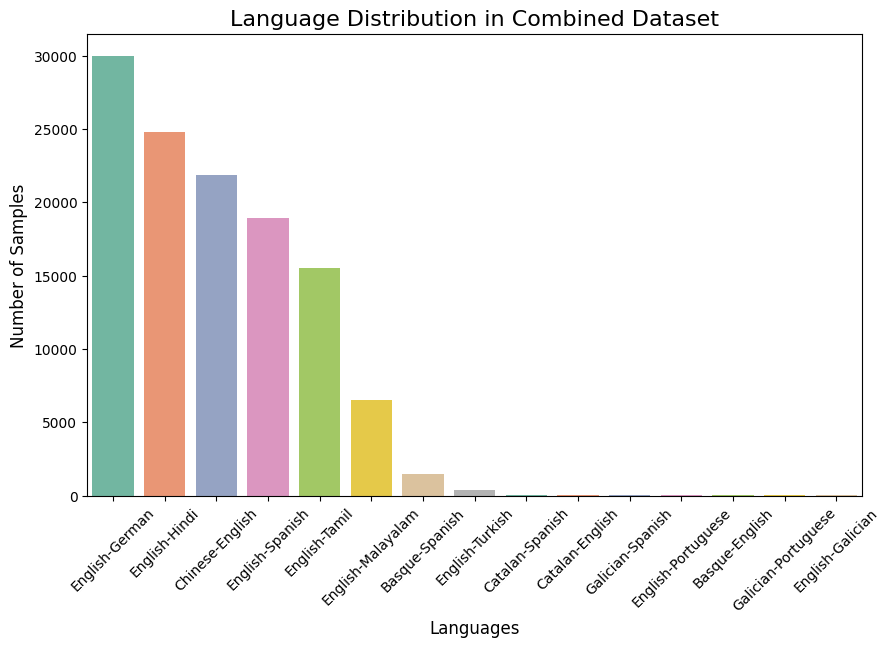

In [1202]:
language_counts = combined_cs_df['languages'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=language_counts.index, y=language_counts.values, palette='Set2')

plt.title('Language Distribution in Combined Dataset', fontsize=16)
plt.xlabel('Languages', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)

plt.xticks(rotation=45)
plt.show()

In [1203]:
combined_cs_df.to_csv('combined_cs_datset.csv', index=False)